# Packages

In [1]:
from pathlib import Path
import scanpy as sc
import pandas as pd

# Data

In [2]:
# Directories
# sc_loc
sc_dir = Path("/home/janzules/spatial/CAR-T/data/sc-reference")
sc_ref_file = sc_dir / "sc_reference_cell2location.h5ad"

In [3]:
sc_ref = sc.read_h5ad(sc_ref_file)

In [4]:
sc_ref

AnnData object with n_obs × n_vars = 135379 × 22949
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Barcode', 'Library', 'condition', 'file_name', 'percent.mt', 'unintegrated_clusters', 'seurat_clusters', 'harmony_clusters', 'sctype_classification', 'seurat.cluster.ann', 'treatment', 'cell_type', 'UMAP_R_1', 'UMAP_R_2'
    obsm: 'X_umap_R'

# Processing

In [6]:
# Keeping raw counts in a layer
sc_ref.layers["counts"] = sc_ref.X.copy()

In [7]:
# Normalization log1p
sc.pp.normalize_total(sc_ref, target_sum=1e4)
sc.pp.log1p(sc_ref)

In [8]:
#Calculate to markers per cell type
sc.tl.rank_genes_groups(
    sc_ref,
    groupby="cell_type",
    method="wilcoxon",
    n_genes=100,
    use_raw=False
)

In [9]:
rg = sc_ref.uns['rank_genes_groups']
groups = rg["names"].dtype.names

markers_df = pd.concat(
    [
        pd.DataFrame({
            "cell_type": g,
            "gene": rg["names"][g],
            "logFC": rg["logfoldchanges"][g],
            "score": rg["scores"][g],
            "pval_adj": rg["pvals_adj"][g],
        })
        for g in groups
    ],
    ignore_index=True
)

markers_df.head()

,cell_type,gene,logFC,score,pval_adj
0,B/T_cell,Skap1,6.455066,20.324234,1.801574e-87
1,B/T_cell,Prkcq,5.883070,20.098915,8.654620e-86
2,B/T_cell,Lef1,6.378878,19.966812,8.190751e-85
3,B/T_cell,Aff3,5.668859,19.877579,3.541106e-84
4,B/T_cell,Bach2,4.807889,19.867908,3.541106e-84


In [10]:
groups

('B/T_cell',
 'B_cell',
 'CAR_T_cell',
 'DC',
 'Endothelial',
 'Erythrocyte',
 'Fibroblast',
 'Macrophage',
 'Monocyte',
 'NK_cell',
 'Neutrophils',
 'T_cell')

In [11]:
markers_df.query("cell_type == 'B_cell'").head(20)

,cell_type,gene,logFC,score,pval_adj
100,B_cell,Bank1,9.645280,127.965469,0.0
101,B_cell,Ebf1,9.847792,127.899612,0.0
102,B_cell,Cd79a,11.058154,125.788307,0.0
103,B_cell,Aff3,6.974793,123.941216,0.0
104,B_cell,Gm43291,11.217458,123.825676,0.0
105,B_cell,Cd79b,9.493780,123.540062,0.0
106,B_cell,Mef2c,4.983974,123.046715,0.0
107,B_cell,Ralgps2,6.913681,122.949745,0.0
108,B_cell,Pax5,10.541492,122.942680,0.0
109,B_cell,Rps27,3.577663,122.844391,0.0


In [13]:
markers_df.query("cell_type == 'DC'").head(20)

,cell_type,gene,logFC,score,pval_adj
300,DC,Syngr2,2.556108,92.821831,0.0
301,DC,Cbfa2t3,2.672763,86.094757,0.0
302,DC,Lsp1,2.052877,84.401520,0.0
303,DC,Fyn,2.312341,83.492386,0.0
304,DC,Cst3,2.106098,82.069778,0.0
305,DC,Tmem131,2.217165,81.365173,0.0
306,DC,Pip4k2a,1.829287,77.888016,0.0
307,DC,Crip1,1.832150,76.042473,0.0
308,DC,Jak2,1.923224,75.816490,0.0
309,DC,Phlpp1,2.222531,75.417511,0.0


In [12]:
markers_df.query("cell_type == 'CAR_T_cell'").head(50)

,cell_type,gene,logFC,score,pval_adj
200,CAR_T_cell,Tmsb4x,2.319820,37.962772,0.000000e+00
201,CAR_T_cell,Ccl5,6.015702,31.363514,4.869445e-212
202,CAR_T_cell,Cst3,2.762070,29.743364,9.698316e-191
203,CAR_T_cell,Calm1,1.947468,28.902206,3.213034e-180
204,CAR_T_cell,Rps19,1.975520,27.618727,1.014434e-164
205,CAR_T_cell,Crip1,2.507615,26.813356,1.918912e-155
206,CAR_T_cell,Fscn1,6.602610,26.698030,4.066352e-154
207,CAR_T_cell,Ccl22,7.045978,25.399504,9.608309e-140
208,CAR_T_cell,Fau,1.372587,24.842823,9.587489e-134
209,CAR_T_cell,Lars2,1.751692,22.973322,1.392572e-114


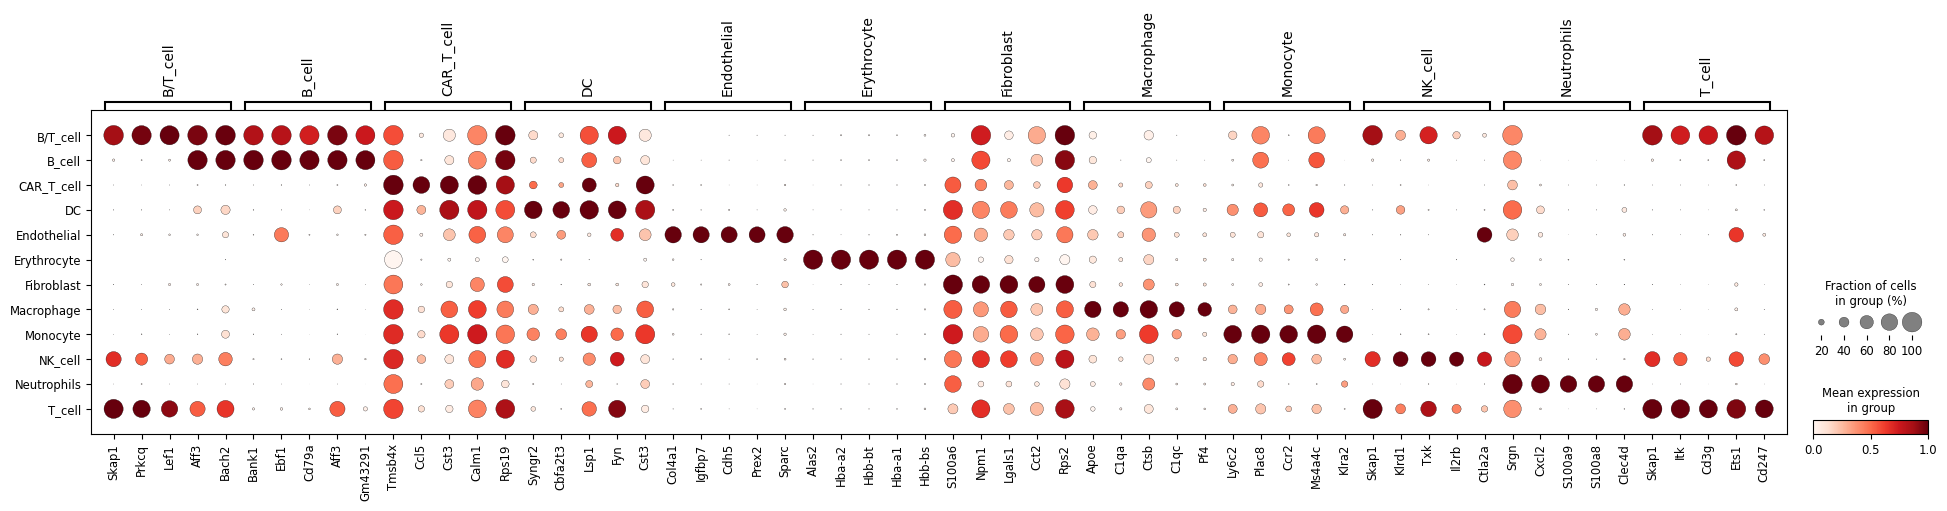

In [39]:
# Cell 4: dotplot of top markers per cell type

top_n = 5

top_markers = (
    markers_df
    .sort_values(["cell_type", "score"], ascending=[True, False])
    .groupby("cell_type")
    .head(top_n)
)

marker_dict = {
    ct: df["gene"].tolist()
    for ct, df in top_markers.groupby("cell_type")
}

sc.pl.dotplot(
    sc_ref,
    var_names=marker_dict,
    groupby="cell_type",
    standard_scale="var",
    dendrogram=False
)


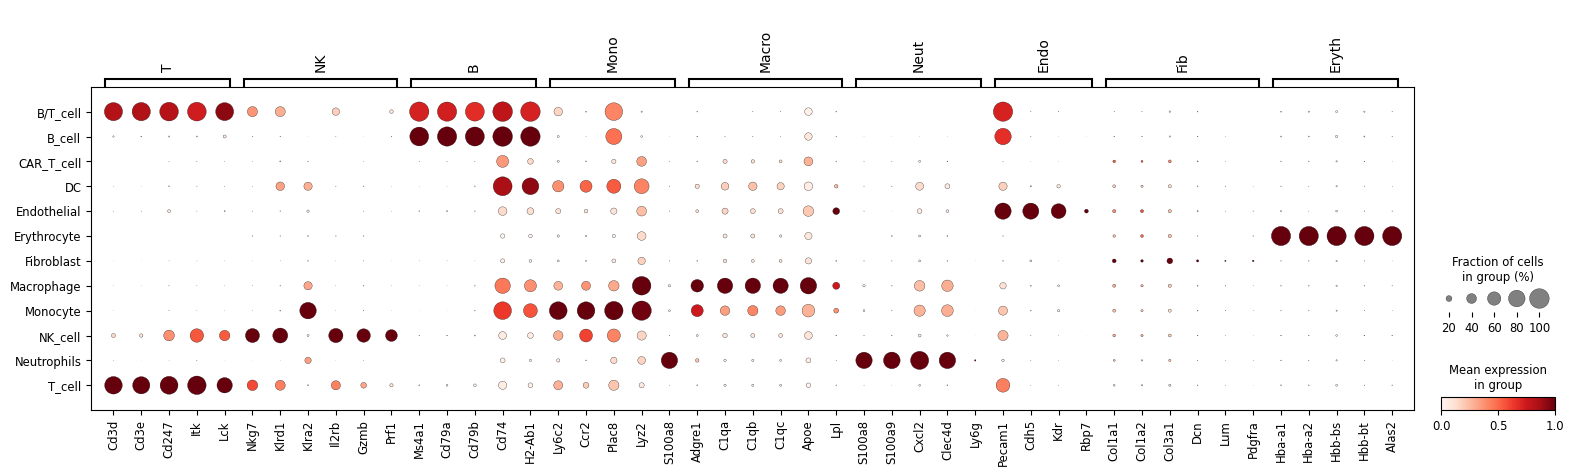

In [42]:
# Cell: curated marker sanity dotplot (much more interpretable than auto-top genes)
marker_sets = {
    "T": ["Cd3d","Cd3e","Cd247","Itk","Lck"], # "Trac"
    "NK": ["Nkg7","Klrd1","Klra2","Il2rb","Gzmb","Prf1"],
    "B": ["Ms4a1","Cd79a","Cd79b","Cd74","H2-Ab1"],
    "Mono": ["Ly6c2","Ccr2","Plac8","Lyz2","S100a8"],
    "Macro": ["Adgre1","C1qa","C1qb","C1qc","Apoe","Lpl"],
    "Neut": ["S100a8","S100a9","Cxcl2","Clec4d","Ly6g"],
    "Endo": ["Pecam1","Cdh5","Kdr","Rbp7"],
    "Fib": ["Col1a1","Col1a2","Col3a1","Dcn","Lum","Pdgfra"],
    "Eryth": ["Hba-a1","Hba-a2","Hbb-bs","Hbb-bt","Alas2"],
}

sc.pl.dotplot(sc_ref, marker_sets, groupby="cell_type", standard_scale="var")


# Quick validations

## CAR_T

In [40]:
# Cell: quick presence check for expected markers
expected_fib = ["Col1a1","Col1a2","Col3a1","Dcn","Lum","Pdgfra"]
expected_car = ["CAR", "PSCA", "Psca"]  # depending on how it was named in your reference

print("Fib markers present:", [g for g in expected_fib if g in sc_ref.var_names])

car_like = [g for g in sc_ref.var_names if any(k.upper() in g.upper() for k in expected_car)]
print("CAR-like genes found:", car_like[:50])
print("...n =", len(car_like))


Fib markers present: ['Col1a1', 'Col1a2', 'Col3a1', 'Dcn', 'Lum', 'Pdgfra']
CAR-like genes found: ['Carf', 'Card9', 'Car5b', 'Car13', 'Car2', 'Bcar3', 'Car8', 'Car9', 'Car6', 'Scarb2', 'Hcar2', 'Scarb1', 'Card11', 'Car11', 'Pycard', 'Cars', 'Ccar1', 'Carkd', 'Cars2', 'Car7', 'Bcar1', 'Car5a', 'Scara5', 'Ccar2', 'Carm1', 'Car12', 'Scarf1', 'Car4', 'Card19', 'Card6', 'Card10', 'Carhsp1', 'Scarf2', 'Carns1', 'Carnmt1', 'Psca', 'Car1', 'Car3', 'Car14', 'Scara3', 'Car10', 'Card14', 'Oscar', 'PSCA', 'Carlr', 'Cartpt', 'Hcar1', 'Car15']
...n = 48


In [43]:
# 1) how many CAR_T cells do you even have?
sc_ref.obs["cell_type"].value_counts().loc[["CAR_T_cell","T_cell","B/T_cell"]]


cell_type
CAR_T_cell     591
T_cell        3031
B/T_cell       152
Name: count, dtype: int64

In [44]:
# 2) does CAR_T look like T in *average expression* of T markers?
import numpy as np
import pandas as pd

t_genes = ["Cd3d","Cd3e","Cd247","Itk","Lck","Trac"]
t_genes = [g for g in t_genes if g in sc_ref.var_names]

avg = sc.get.obs_df(sc_ref, keys=t_genes + ["cell_type"]).groupby("cell_type")[t_genes].mean()
avg.loc[["CAR_T_cell","T_cell"]]


/tmp/ipykernel_2106475/1823578038.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = sc.get.obs_df(sc_ref, keys=t_genes + ["cell_type"]).groupby("cell_type")[t_genes].mean()


,Cd3d,Cd3e,Cd247,Itk,Lck
cell_type,,,,,
CAR_T_cell,0.000000,0.000000,0.007879,0.010421,0.007984
T_cell,1.576787,1.392202,1.629475,1.930467,1.008347


### Is Car_T scrambled?

In [45]:
# Cell: barcode alignment sanity
if "Barcode" in sc_ref.obs.columns:
    frac_match = (sc_ref.obs_names.astype(str) == sc_ref.obs["Barcode"].astype(str)).mean()
    print("obs_names == obs['Barcode'] fraction:", frac_match)
else:
    print("No obs['Barcode'] column found.")


obs_names == obs['Barcode'] fraction: 0.0


In [48]:
# Cell: inspect ID formats
print("obs_names head:", list(sc_ref.obs_names[:5]))
print("obs['Barcode'] head:", list(sc_ref.obs["Barcode"].astype(str).head(5)))


obs_names head: ['56948_AAACGAACACTAGGTT-1', '56948_AAACGCTGTTGGGTTT-1', '56948_AAACGCTTCCTCGATC-1', '56948_AAAGAACCAATACAGA-1', '56948_AAAGAACCACAGGATG-1']
obs['Barcode'] head: ['AAACGAACACTAGGTT-1', 'AAACGCTGTTGGGTTT-1', 'AAACGCTTCCTCGATC-1', 'AAAGAACCAATACAGA-1', 'AAAGAACCACAGGATG-1']


In [51]:
# Cell: create a barcode that matches obs_names format

# Extract the prefix from obs_names (everything before first "_")
prefix = sc_ref.obs_names[0].split("_")[0]
print("Detected prefix:", prefix)

# Create a full barcode that matches obs_names
sc_ref.obs["Barcode_full"] = prefix + "_" + sc_ref.obs["Barcode"].astype(str)

# Check match
frac_match = (sc_ref.obs_names.astype(str) == sc_ref.obs["Barcode_full"].astype(str)).mean()
print("obs_names == obs['Barcode_full'] fraction:", frac_match)


Detected prefix: 56948
obs_names == obs['Barcode_full'] fraction: 0.012549952355978401


In [50]:
# Cell: robust per-row prefix extraction from obs_names

obs_prefix = pd.Index(sc_ref.obs_names.astype(str)).str.split("_").str[0]
obs_bc     = pd.Index(sc_ref.obs_names.astype(str)).str.split("_").str[1]

# sanity
print("Example parsed from obs_names:", obs_prefix[0], obs_bc[0])

# check if obs['Barcode'] matches the suffix part of obs_names
frac_suffix_match = (sc_ref.obs["Barcode"].astype(str).values == obs_bc.values).mean()
print("obs['Barcode'] matches suffix of obs_names fraction:", frac_suffix_match)


Example parsed from obs_names: 56948 AAACGAACACTAGGTT-1
obs['Barcode'] matches suffix of obs_names fraction: 1.0


In [52]:
#Barcdoe alignment is fine, there is something wrong with the CAR_T cell labels:

### What are these CAR-T cell lables?

In [53]:
# Cell: what lineage does CAR_T_cell look like?

import scanpy as sc

genes = [g for g in ["Ptprc","Cd3d","Cd3e","Trac","Nkg7","Klrd1","Prf1","Gzmb","Lyz2","S100a8","S100a9","Epcam","Krt8","Psca"] if g in sc_ref.var_names]

avg = sc.get.obs_df(sc_ref, keys=genes + ["cell_type"]).groupby("cell_type", observed=True)[genes].mean()
avg.loc[[ct for ct in ["CAR_T_cell","T_cell","NK_cell","Monocyte","Macrophage"] if ct in avg.index]]


,Ptprc,Cd3d,Cd3e,Nkg7,Klrd1,Prf1,Gzmb,Lyz2,S100a8,S100a9,Epcam,Krt8,Psca
cell_type,,,,,,,,,,,,,
CAR_T_cell,0.243568,0.000000,0.000000,0.006777,0.047931,0.000000,0.007621,1.212611,0.011795,0.011987,0.004674,0.038514,0.002437
T_cell,2.841846,1.576787,1.392202,0.701922,0.610500,0.084187,0.474531,0.247013,0.004391,0.002708,0.018876,0.007926,0.000595
NK_cell,2.387120,0.217346,0.163807,1.200071,1.399731,0.783970,1.486019,0.591649,0.014783,0.016510,0.016380,0.021763,0.000459
Monocyte,2.512037,0.001096,0.000333,0.002051,0.013878,0.001164,0.007224,3.549112,0.054543,0.011789,0.001507,0.022784,0.002437
Macrophage,1.726364,0.002194,0.001818,0.003571,0.013260,0.002094,0.010087,3.612881,0.057863,0.017182,0.001872,0.032336,0.002434


## Testing

In [19]:
rg.keys()

dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])

In [27]:
groups = rg["names"].dtype.names

In [30]:
groups

('B/T_cell',
 'B_cell',
 'CAR_T_cell',
 'DC',
 'Endothelial',
 'Erythrocyte',
 'Fibroblast',
 'Macrophage',
 'Monocyte',
 'NK_cell',
 'Neutrophils',
 'T_cell')

In [29]:
rg["names"]

rec.array([('Skap1', 'Bank1', 'Tmsb4x', 'Syngr2', 'Col4a1', 'Alas2', 'S100a6', 'Apoe', 'Ly6c2', 'Skap1', 'Srgn', 'Skap1'),
           ('Prkcq', 'Ebf1', 'Ccl5', 'Cbfa2t3', 'Igfbp7', 'Hba-a2', 'Npm1', 'C1qa', 'Plac8', 'Klrd1', 'Cxcl2', 'Itk'),
           ('Lef1', 'Cd79a', 'Cst3', 'Lsp1', 'Cdh5', 'Hbb-bt', 'Lgals1', 'Ctsb', 'Ccr2', 'Txk', 'S100a9', 'Cd3g'),
           ('Aff3', 'Aff3', 'Calm1', 'Fyn', 'Prex2', 'Hba-a1', 'Cct2', 'C1qc', 'Ms4a4c', 'Il2rb', 'S100a8', 'Ets1'),
           ('Bach2', 'Gm43291', 'Rps19', 'Cst3', 'Sparc', 'Hbb-bs', 'Rps2', 'Pf4', 'Klra2', 'Ctla2a', 'Clec4d', 'Cd247'),
           ('Rps29', 'Cd79b', 'Crip1', 'Tmem131', 'Col4a2', 'Bpgm', 'Lars2', 'C1qb', 'Ms4a6c', 'Nkg7', 'Il1b', 'Ms4a4b'),
           ('Cmah', 'Mef2c', 'Fscn1', 'Pip4k2a', 'Cyyr1', 'Snca', 'mt-Atp6', 'Lgmn', 'Gpr141', 'Gzmb', 'Hdc', 'Cd3d'),
           ('Rps27', 'Ralgps2', 'Ccl22', 'Crip1', 'Tcf4', 'Fam46c', 'Ppia', 'Ctsd', 'Tgfbi', 'Ptpn22', 'Cebpb', 'Bcl11b'),
           ('Satb1', 'Pax5', 'Fau', 'Jak

In [28]:
groups

('B/T_cell',
 'B_cell',
 'CAR_T_cell',
 'DC',
 'Endothelial',
 'Erythrocyte',
 'Fibroblast',
 'Macrophage',
 'Monocyte',
 'NK_cell',
 'Neutrophils',
 'T_cell')

# UMAP

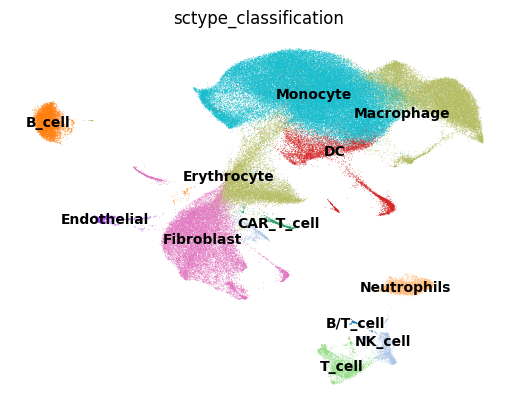

In [7]:
import scanpy as sc

# make sure it's treated as categorical (better colors/legend)
sc_ref.obs["sctype_classification"] = sc_ref.obs["sctype_classification"].astype("category")

# Plot the embedding stored in obsm["X_umap_R"]  (basis name is "umap_R")
sc.pl.embedding(
    sc_ref,
    basis="umap_R",
    color="sctype_classification",
    legend_loc="on data",   # try also: "right margin"
    frameon=False,
    size=1
)


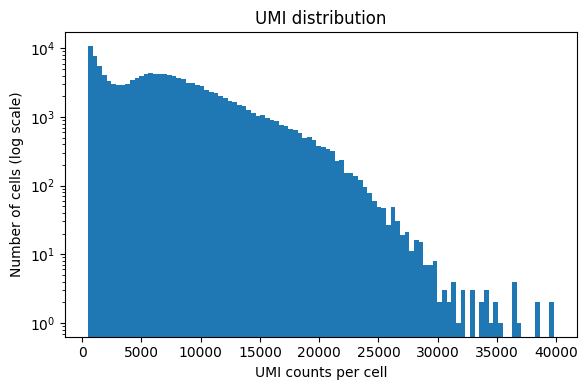

In [8]:
import matplotlib.pyplot as plt
import numpy as np

umi = sc_ref.obs["nCount_RNA"]

plt.figure(figsize=(6, 4))
plt.hist(umi, bins=100, log=True)
plt.xlabel("UMI counts per cell")
plt.ylabel("Number of cells (log scale)")
plt.title("UMI distribution")
plt.tight_layout()
plt.show()
